In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(
    '../Dataset/loan_approval_data.xlsx',
    engine='openpyxl'
)

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependency,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Status
0,LP001000,Male,No,0,Graduate,No,10287.0,180.0,Y
1,LP001001,NaN,Yes,0,Graduate,No,8731.0,112.0,Y
2,LP001002,Female,Yes,2,Graduate,No,5761.0,151.0,N
3,LP001003,Male,No,2,Graduate,No,17123.0,177.0,Y
4,LP001004,Male,No,2,Graduate,No,2619.0,138.0,N


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          500 non-null    object 
 1   Gender           470 non-null    object 
 2   Married          490 non-null    object 
 3   Dependency       480 non-null    object 
 4   Education        488 non-null    object 
 5   Self_Employed    474 non-null    object 
 6   ApplicantIncome  479 non-null    float64
 7   LoanAmount       480 non-null    float64
 8   Loan_Status      500 non-null    object 
dtypes: float64(2), object(7)
memory usage: 35.3+ KB


In [6]:
df.isnull().sum()

Loan_ID             0
Gender             30
Married            10
Dependency         20
Education          12
Self_Employed      26
ApplicantIncome    21
LoanAmount         20
Loan_Status         0
dtype: int64

In [7]:
gen=df['Gender'].mode()[0]
df['Gender'].fillna(value=gen, inplace=True)


mar=df['Married'].mode()[0]
mar
df['Married'].fillna(value=mar, inplace=True)



dep=df['Dependency'].mode()[0]
dep
df['Dependency'].fillna(value=dep, inplace=True)

edu=df['Education'].mode()[0]
edu
df['Education'].fillna(value=edu, inplace=True)



emp=df['Self_Employed'].mode()[0]
emp
df['Self_Employed'].fillna(value=emp, inplace=True)

num_cols = [
    'ApplicantIncome',
    'LoanAmount'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13536\3692869873.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(value=gen, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13536\3692869873.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [8]:
df.select_dtypes(['int64','float64']).columns

nums='ApplicantIncome', 'LoanAmount'
# cat=

In [9]:
df.select_dtypes(['object']).columns
num='Gender', 'Married', 'Dependency', 'Education','Self_Employed'

In [10]:
# Features
x = df.drop("Loan_Status", axis=1)

# Target
y = df['Loan_Status'].map({
    'Y':1,
    'N':0
})

In [11]:
df.isnull().sum()

Loan_ID            0
Gender             0
Married            0
Dependency         0
Education          0
Self_Employed      0
ApplicantIncome    0
LoanAmount         0
Loan_Status        0
dtype: int64

In [12]:
x.dtypes

Loan_ID             object
Gender              object
Married             object
Dependency          object
Education           object
Self_Employed       object
ApplicantIncome    float64
LoanAmount         float64
dtype: object

In [13]:
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['Loan_ID', 'Gender', 'Married', 'Dependency', 'Education',
       'Self_Employed'],
      dtype='object')
Index(['ApplicantIncome', 'LoanAmount'], dtype='object')


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",    sparse_output=False
))
])

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
x_train = preprocessor.fit_transform(x_train)

x_test = preprocessor.transform(x_test)

In [18]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__ApplicantIncome' 'num__LoanAmount' 'cat__Loan_ID_LP001001'
 'cat__Loan_ID_LP001003' 'cat__Loan_ID_LP001004' 'cat__Loan_ID_LP001005'
 'cat__Loan_ID_LP001006' 'cat__Loan_ID_LP001007' 'cat__Loan_ID_LP001008'
 'cat__Loan_ID_LP001010' 'cat__Loan_ID_LP001012' 'cat__Loan_ID_LP001013'
 'cat__Loan_ID_LP001014' 'cat__Loan_ID_LP001016' 'cat__Loan_ID_LP001017'
 'cat__Loan_ID_LP001019' 'cat__Loan_ID_LP001020' 'cat__Loan_ID_LP001021'
 'cat__Loan_ID_LP001023' 'cat__Loan_ID_LP001024' 'cat__Loan_ID_LP001025'
 'cat__Loan_ID_LP001026' 'cat__Loan_ID_LP001027' 'cat__Loan_ID_LP001028'
 'cat__Loan_ID_LP001029' 'cat__Loan_ID_LP001031' 'cat__Loan_ID_LP001032'
 'cat__Loan_ID_LP001034' 'cat__Loan_ID_LP001035' 'cat__Loan_ID_LP001036'
 'cat__Loan_ID_LP001037' 'cat__Loan_ID_LP001038' 'cat__Loan_ID_LP001040'
 'cat__Loan_ID_LP001041' 'cat__Loan_ID_LP001042' 'cat__Loan_ID_LP001043'
 'cat__Loan_ID_LP001044' 'cat__Loan_ID_LP001045' 'cat__Loan_ID_LP001047'
 'cat__Loan_ID_LP001048' 'cat__Loan_ID_LP001049' 'cat__Loa

In [19]:
print(x_train.shape)
print(x_test.shape)

(400, 414)
(100, 414)


In [20]:
from sklearn.tree import DecisionTreeClassifier

# for depth in [2, 3, 4, 5, 6, 7, 8, 10]:
#     dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
#     dt.fit(x_train, y_train)

#     print(
#         depth,
#         dt.score(x_train, y_train),
#         dt.score(x_test, y_test)
#     )

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)
from sklearn.metrics import accuracy_score

train_acc = dt.score(x_train, y_train)
test_acc = dt.score(x_test, y_test)

print("Train Accuracy :", train_acc)
print("Test Accuracy :", test_acc)
print("Depth :", dt.get_depth())
print("Leaves :", dt.get_n_leaves())

Train Accuracy : 0.7525
Test Accuracy : 0.75
Depth : 3
Leaves : 8


In [21]:
print(type(x_train))
print(x_train.shape)

<class 'numpy.ndarray'>
(400, 414)


In [22]:
print(type(x_test))
print(type(x_train))
print(type(dt))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


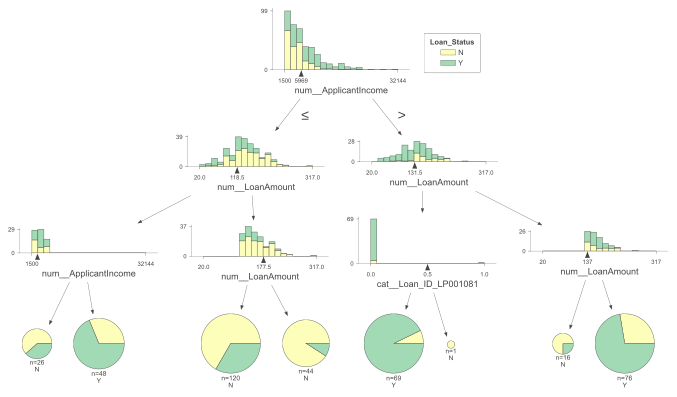

In [23]:
from dtreeviz import model

viz = model(
    dt,
    X_train=x_train,
    y_train=y_train,
    feature_names=feature_names,
    target_name="Loan_Status",
    class_names=["N", "Y"]
)

viz.view()

In [24]:
preprocessor.get_feature_names_out()

array(['num__ApplicantIncome', 'num__LoanAmount', 'cat__Loan_ID_LP001001',
       'cat__Loan_ID_LP001003', 'cat__Loan_ID_LP001004',
       'cat__Loan_ID_LP001005', 'cat__Loan_ID_LP001006',
       'cat__Loan_ID_LP001007', 'cat__Loan_ID_LP001008',
       'cat__Loan_ID_LP001010', 'cat__Loan_ID_LP001012',
       'cat__Loan_ID_LP001013', 'cat__Loan_ID_LP001014',
       'cat__Loan_ID_LP001016', 'cat__Loan_ID_LP001017',
       'cat__Loan_ID_LP001019', 'cat__Loan_ID_LP001020',
       'cat__Loan_ID_LP001021', 'cat__Loan_ID_LP001023',
       'cat__Loan_ID_LP001024', 'cat__Loan_ID_LP001025',
       'cat__Loan_ID_LP001026', 'cat__Loan_ID_LP001027',
       'cat__Loan_ID_LP001028', 'cat__Loan_ID_LP001029',
       'cat__Loan_ID_LP001031', 'cat__Loan_ID_LP001032',
       'cat__Loan_ID_LP001034', 'cat__Loan_ID_LP001035',
       'cat__Loan_ID_LP001036', 'cat__Loan_ID_LP001037',
       'cat__Loan_ID_LP001038', 'cat__Loan_ID_LP001040',
       'cat__Loan_ID_LP001041', 'cat__Loan_ID_LP001042',
       'cat__

In [25]:
type(x_train)

numpy.ndarray

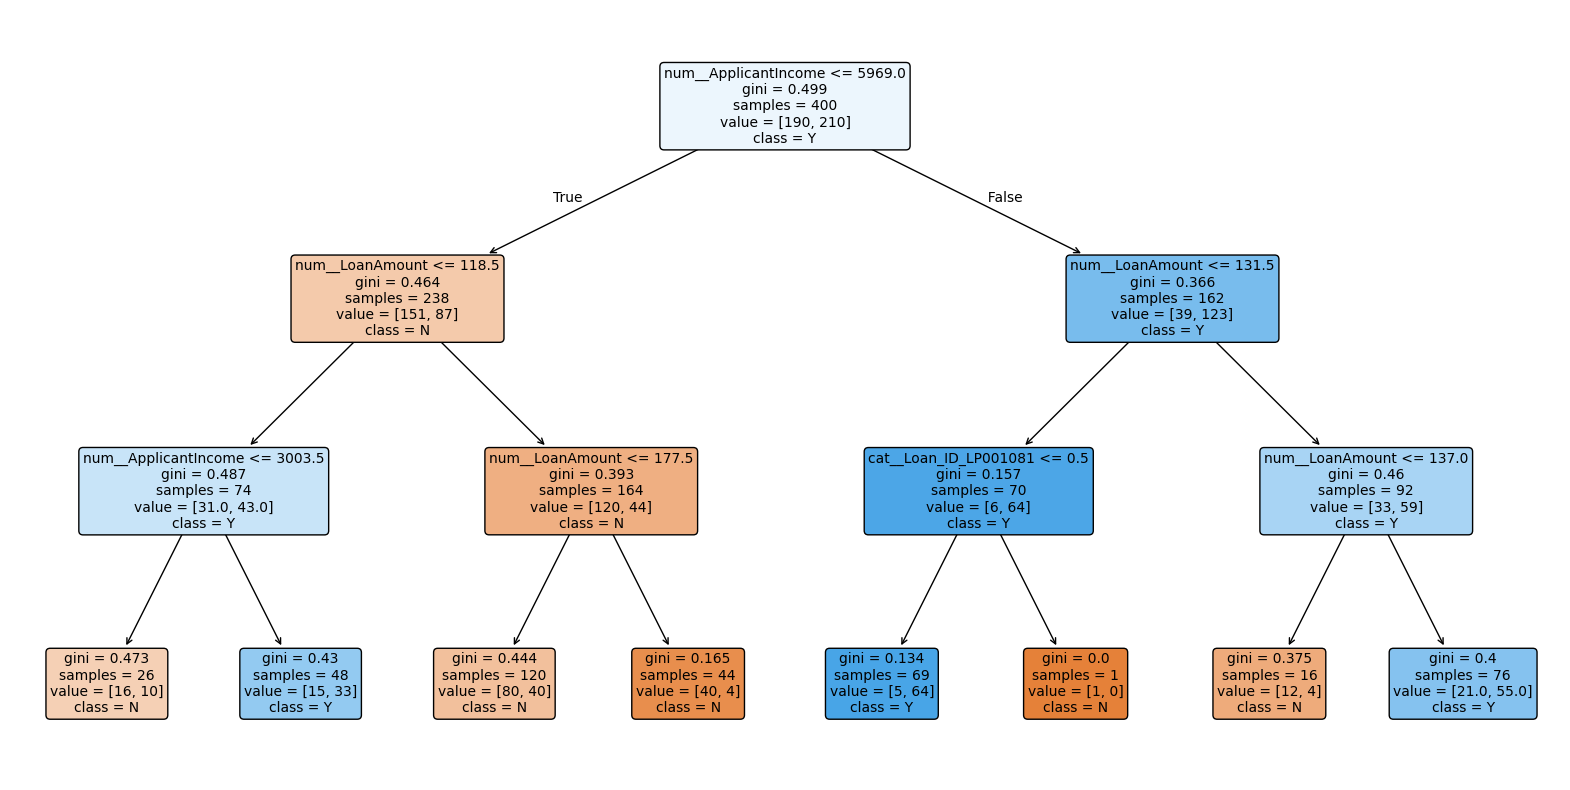

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["N", "Y"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()